In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
csv_path = '/home/thsu/FRB_population/chimefrbcat2.csv'
df = pd.read_csv(csv_path)




Power-law fit (SNR > 12):
  Slope: α = -1.525
  Number of bins: 26
  SNR range: [13.0, 890.7]


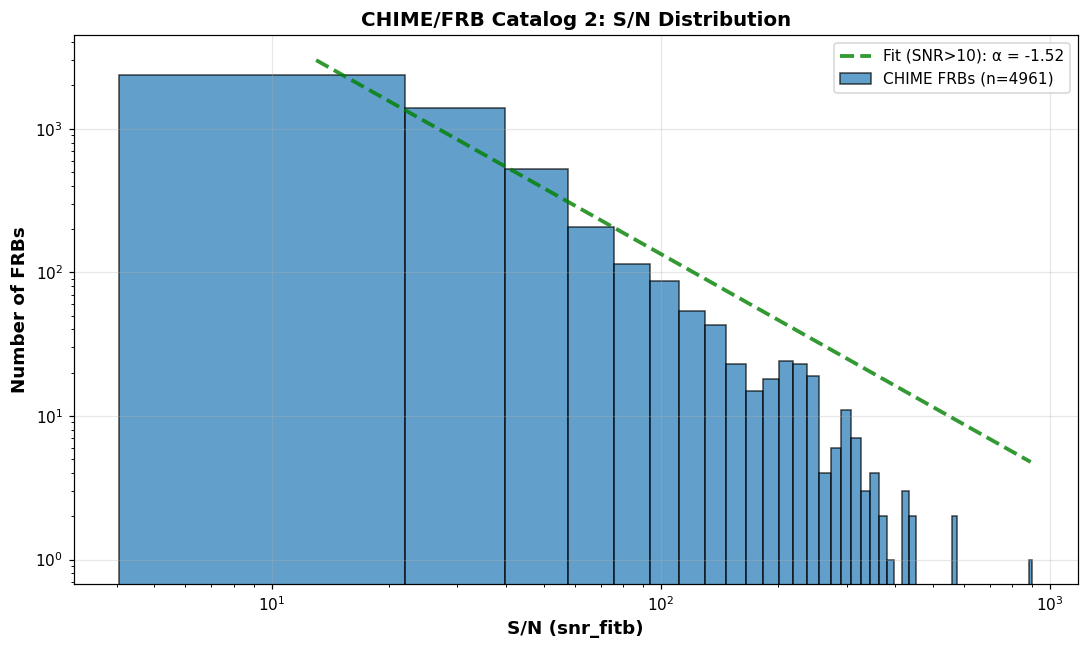


CHIME/FRB CATALOG2 - S/N STATISTICS

Total FRBs: 4961
Mean S/N: 37.78
Median S/N: 22.83
Min S/N: 4.06
Max S/N: 899.63


In [8]:
# Extract the snr_fitb column
snr_fitb = df['snr_fitb'].dropna()  # Remove NaN values

# Plot histogram
plt.figure(figsize=(10, 6), dpi=110)

counts, bins, patches = plt.hist(snr_fitb, bins=50, alpha=0.7, color='tab:blue', 
                                 edgecolor='black', label=f'CHIME FRBs (n={len(snr_fitb)})')

# Add statistics
# plt.axvline(np.median(snr_fitb), color='red', linestyle='--', linewidth=2.5, 
#            label=f'Median: {np.median(snr_fitb):.2f}')
# plt.axvline(np.mean(snr_fitb), color='orange', linestyle=':', linewidth=2.5, 
#            label=f'Mean: {np.mean(snr_fitb):.2f}')

# === SLOPE FITTING ===
valid_bins = counts > 0
bin_centers = (bins[:-1] + bins[1:])[valid_bins] / 2
valid_counts = counts[valid_bins]

# Fit only SNR > 12 (avoiding threshold effects)
fit_mask = bin_centers > 10

if np.sum(fit_mask) >= 5:
    log_snr_fit = np.log10(bin_centers[fit_mask])
    log_counts_fit = np.log10(valid_counts[fit_mask])
    
    # Weighted fit
    weights = np.sqrt(valid_counts[fit_mask])
    slope, intercept = np.polyfit(log_snr_fit, log_counts_fit, 1, w=weights)
    
    # Plot the fit line
    snr_fit_range = np.logspace(np.log10(bin_centers[fit_mask].min()), 
                                np.log10(bin_centers.max()), 100)
    counts_fit = 10**(intercept + slope * np.log10(snr_fit_range))
    
    plt.plot(snr_fit_range, counts_fit, 'green', linestyle='--', linewidth=2.5, alpha=0.8,
             label=f'Fit (SNR>10): α = {slope:.2f}')
    
    print(f"\nPower-law fit (SNR > 12):")
    print(f"  Slope: α = {slope:.3f}")
    print(f"  Number of bins: {np.sum(fit_mask)}")
    print(f"  SNR range: [{bin_centers[fit_mask].min():.1f}, {bin_centers.max():.1f}]")

plt.xlabel('S/N (snr_fitb)', fontsize=12, fontweight='bold')
plt.ylabel('Number of FRBs', fontsize=12, fontweight='bold')
plt.title('CHIME/FRB Catalog 2: S/N Distribution', fontsize=13, fontweight='bold')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\n{'='*60}")
print(f"CHIME/FRB CATALOG2 - S/N STATISTICS")
print(f"{'='*60}")
print(f"\nTotal FRBs: {len(snr_fitb)}")
print(f"Mean S/N: {np.mean(snr_fitb):.2f}")
print(f"Median S/N: {np.median(snr_fitb):.2f}")
print(f"Min S/N: {np.min(snr_fitb):.2f}")
print(f"Max S/N: {np.max(snr_fitb):.2f}")
print(f"{'='*60}")

